## Objectives

After completing this lab you will be able to:

*   Load and explore the Student Performance dataset
*   Perform data cleaning, validation, and outlier handling
*   Perform feature engineering (creating composite scores and performance changes)
*   Encode binary and nominal categorical variables into numeric values
*   Split the dataset into training and testing sets
*   Scale numerical features using StandardScaler to prevent data leakage

In this lab exercise, you will learn how to preprocess and explore the Student Performance dataset from the UCI Machine Learning Repository. You will load the data for the Mathematics course, perform exploratory data analysis, clean the variables, engineer new informative features, encode categorical inputs, and scale numeric attributes. These steps will prepare a clean, finalized feature matrix and target vector ready for training regression and classification machine learning models to predict students' final period grades ($G3$).

<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#about_dataset">About the Dataset</a></li>
        <li><a href="#load_data">Load the Data</a></li>
        <li><a href="#explore_data">Explore the Data</a></li>
        <li><a href="#preprocessing">Pre-processing</a></li>
    </ol>
</div>
<br>
<hr>

Import the Following Libraries:

<ul>
    <li> <b>numpy as np</b> </li>
    <li> <b>pandas as pd</b> </li>
    <li> <b>matplotlib.pyplot as plt</b> </li>
    <li> <b>seaborn as sns</b> </li>
    <li> <b>train_test_split</b> from <b>sklearn.model_selection</b> </li>
    <li> <b>LabelEncoder</b> and <b>StandardScaler</b> from <b>sklearn.preprocessing</b> </li>
</ul>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set random seed for reproducibility
np.random.seed(42)

<div id="about_dataset">
    <h2>About the Dataset</h2>
    This dataset contains student performance data in secondary education from two Portuguese schools: Gabriel Pereira (GP) and Mousinho da Silveira (MS). The data is collected for two subjects: Mathematics and Portuguese language. The target is the student's final grade ($G3$), measured on a scale from 0 to 20.
    <br>
    <br>
    The goal is to build a machine learning model to predict final academic performance using demographic, socio-economic, personal, and academic attributes.
    <br>
    <br>
    Typical features in the dataset:
    <li><b>school:</b> student's school (binary: GP or MS)</li>
    <li><b>sex:</b> student's sex (binary: F or M)</li>
    <li><b>age:</b> student's age (numeric: 15 to 22)</li>
    <li><b>address:</b> student's home address type (binary: U or R)</li>
    <li><b>famsize:</b> family size (binary: LE3 or GT3)</li>
    <li><b>Pstatus:</b> parent's cohabitation status (binary: T or A)</li>
    <li><b>Medu / Fedu:</b> mother's and father's education (numeric: 0-4)</li>
    <li><b>Mjob / Fjob:</b> mother's and father's job (nominal: teacher, health, services, at_home, other)</li>
    <li><b>reason:</b> reason to choose this school (nominal: home, reputation, course, other)</li>
    <li><b>guardian:</b> student's guardian (nominal: mother, father, other)</li>
    <li><b>traveltime / studytime:</b> home-to-school travel time / weekly study time (numeric)</li>
    <li><b>failures:</b> number of past class failures (numeric)</li>
    <li><b>schoolsup / famsup / paid:</b> extra educational support / family support / extra paid classes (binary: yes/no)</li>
    <li><b>activities / nursery / higher / internet / romantic:</b> extracurriculars / nursery / wants higher ed / internet / romantic relationship (binary: yes/no)</li>
    <li><b>famrel / freetime / goout:</b> family relationship quality / free time / going out (numeric: 1-5)</li>
    <li><b>Dalc / Walc:</b> workday / weekend alcohol consumption (numeric: 1-5)</li>
    <li><b>health:</b> current health status (numeric: 1-5)</li>
    <li><b>absences:</b> number of school absences (numeric: 0-93)</li>
    <li><b>G1 / G2:</b> first and second period grades (numeric: 0-20)</li>
    <li><b>G3:</b> final period grade (target, numeric: 0-20)</li>
</div>

<div id="load_data">
    <h2>Load the Data</h2>
</div>

Now, load the dataset using pandas dataframe. We will load the Mathematics course dataset (`student-mat.csv`) which is semicolon-separated:

In [ ]:
# Load the datasets
student_mat = pd.read_csv('student-mat.csv', sep=';')
student_por = pd.read_csv('student-por.csv', sep=';')

# By default, define student_data as student_mat to run the rest of the notebook analysis on the Math dataset
student_data = student_mat

# Display the first few rows of both datasets
print("Mathematics Dataset:")
display(student_mat.head())

print("\nPortuguese Dataset:")
display(student_por.head())

Mathematics Dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Portuguese Dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


<div id="explore_data">
    <h2>Explore the Data</h2>
    What is the size of the data?
    What are the descriptive statistics of the data?
</div>

In [ ]:
# Print dataset sizes (rows, columns) for both Math and Portuguese
print("Mathematics Dataset size:", student_mat.shape)
print("Portuguese Dataset size:", student_por.shape)

# Print descriptive statistics for numeric attributes
print("\nMathematics Dataset Description:")
display(student_mat[['age', 'absences', 'G1', 'G2', 'G3']].describe())

print("\nPortuguese Dataset Description:")
display(student_por[['age', 'absences', 'G1', 'G2', 'G3']].describe())

Mathematics Dataset size: (395, 33)
Portuguese Dataset size: (649, 33)

Mathematics Dataset Description:


,age,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,5.708861,10.908861,10.713924,10.415190
std,1.276043,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,75.000000,19.000000,19.000000,20.000000



Portuguese Dataset Description:


,age,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,3.659476,11.399076,11.570108,11.906009
std,1.218138,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,32.000000,19.000000,19.000000,19.000000


Let's check the distributions of our target variable ($G3$) and school absences:

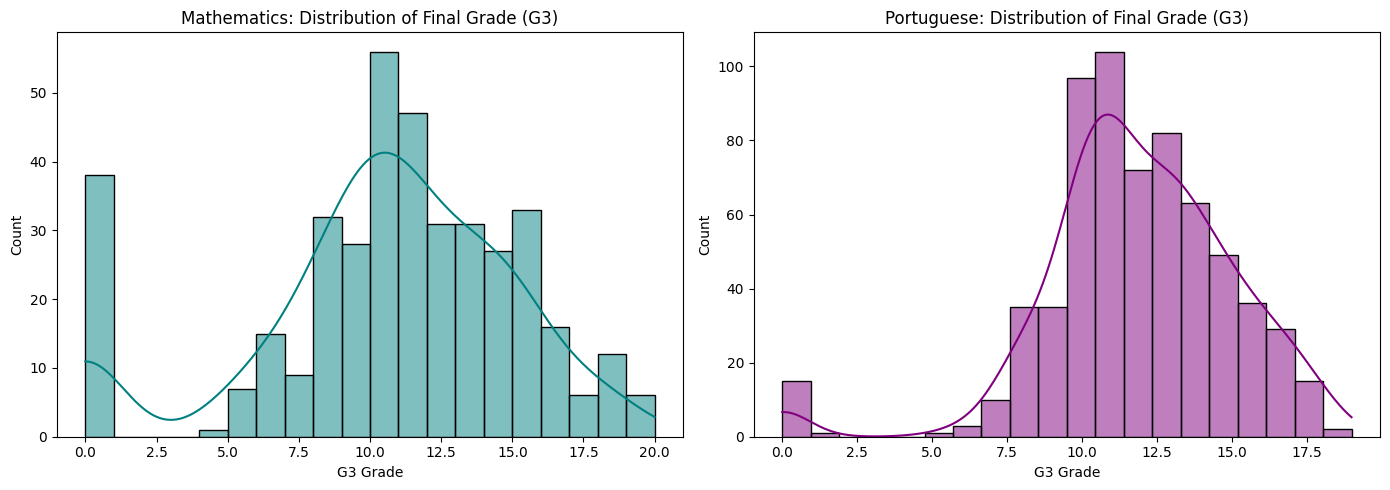

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Math G3 distribution
sns.histplot(student_mat['G3'], bins=20, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Mathematics: Distribution of Final Grade (G3)')
axes[0].set_xlabel('G3 Grade')

# Portuguese G3 distribution
sns.histplot(student_por['G3'], bins=20, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Portuguese: Distribution of Final Grade (G3)')
axes[1].set_xlabel('G3 Grade')

plt.tight_layout()
plt.show()


<div id="preprocessing">
    <h2>Pre-processing</h2>
</div>


To prepare our dataset for machine learning models, we implement several key preprocessing steps:
<ol>
    <li><b>Data Cleaning & Range Validation:</b> Handling duplicates, validating grade bounds, and managing outliers (capping absences).</li>
    <li><b>Feature Engineering:</b> Creating composite scores (family support composite) and progress markers (grade improvement).</li>
    <li><b>Categorical Feature Encoding:</b> Transforming text variables to numeric values using label mapping and One-Hot Encoding.</li>
    <li><b>Train-Test Split:</b> Splitting our features and targets into training (80%) and testing (20%) subsets.</li>
    <li><b>Feature Scaling:</b> Scaling continuous variables to prevent scale dominance in SVR/Linear Regression.</li>
</ol>

<h3>Step 1: Data Cleaning & Validation</h3>
Let's check for missing values, verify duplicates, validate that grades are within the $[0,20]$ range, and clip extreme outlier absences at 50 to prevent them from distorting distance-based algorithms.

In [ ]:
# Check for missing values in both datasets
print("Missing values in Mathematics:", student_mat.isnull().sum().sum())
print("Missing values in Portuguese:", student_por.isnull().sum().sum())

# Drop duplicates and validate grade ranges for Mathematics
df_mat_clean = student_mat.drop_duplicates()
df_mat_clean = df_mat_clean[(df_mat_clean['G1'] >= 0) & (df_mat_clean['G1'] <= 20)]
df_mat_clean = df_mat_clean[(df_mat_clean['G2'] >= 0) & (df_mat_clean['G2'] <= 20)]
df_mat_clean = df_mat_clean[(df_mat_clean['G3'] >= 0) & (df_mat_clean['G3'] <= 20)]
df_mat_clean['absences'] = df_mat_clean['absences'].clip(upper=50)

# Drop duplicates and validate grade ranges for Portuguese
df_por_clean = student_por.drop_duplicates()
df_por_clean = df_por_clean[(df_por_clean['G1'] >= 0) & (df_por_clean['G1'] <= 20)]
df_por_clean = df_por_clean[(df_por_clean['G2'] >= 0) & (df_por_clean['G2'] <= 20)]
df_por_clean = df_por_clean[(df_por_clean['G3'] >= 0) & (df_por_clean['G3'] <= 20)]
df_por_clean['absences'] = df_por_clean['absences'].clip(upper=50)

print(f"\nMathematics shape after cleaning & validation: {df_mat_clean.shape}")
print(f"Portuguese shape after cleaning & validation: {df_por_clean.shape}")

# Maintain df_clean as the Math clean dataset for the rest of the Math pipeline
df_clean = df_mat_clean

Missing values in Mathematics: 0
Missing values in Portuguese: 0

Mathematics shape after cleaning & validation: (395, 33)
Portuguese shape after cleaning & validation: (649, 33)


<h3>Step 2: Feature Engineering</h3>
Following our proposal, we engineer three key features:
<ul>
    <li><b>grade_improvement:</b> The difference between the second and first period grades ($G2 - G1$).</li>
    <li><b>average_early_grade:</b> The mean of the first two period grades ($\frac{G1 + G2}{2}$).</li>
    <li><b>family_support_composite:</b> A composite index measuring overall family support, defined as:
        $$\text{famsup\_bin} + \text{Pstatus\_bin} + \text{Medu} + \text{Fedu}$$
        where `famsup` yes/no is mapped to 1/0, `Pstatus` T/A is mapped to 1/0, and `Medu` and `Fedu` represent parents' education levels (0-4).
    </li>
</ul>

In [ ]:
# Feature Engineering for Mathematics dataset
df_mat_clean['grade_improvement'] = df_mat_clean['G2'] - df_mat_clean['G1']
df_mat_clean['average_early_grade'] = (df_mat_clean['G1'] + df_mat_clean['G2']) / 2
famsup_bin_mat = df_mat_clean['famsup'].map({'yes': 1, 'no': 0})
pstatus_bin_mat = df_mat_clean['Pstatus'].map({'T': 1, 'A': 0})
df_mat_clean['family_support_composite'] = famsup_bin_mat + pstatus_bin_mat + df_mat_clean['Medu'] + df_mat_clean['Fedu']

# Feature Engineering for Portuguese dataset
df_por_clean['grade_improvement'] = df_por_clean['G2'] - df_por_clean['G1']
df_por_clean['average_early_grade'] = (df_por_clean['G1'] + df_por_clean['G2']) / 2
famsup_bin_por = df_por_clean['famsup'].map({'yes': 1, 'no': 0})
pstatus_bin_por = df_por_clean['Pstatus'].map({'T': 1, 'A': 0})
df_por_clean['family_support_composite'] = famsup_bin_por + pstatus_bin_por + df_por_clean['Medu'] + df_por_clean['Fedu']

# Keep df_clean synced
df_clean = df_mat_clean

print("Mathematics Engineered Features Summary:")
display(df_mat_clean[['grade_improvement', 'average_early_grade', 'family_support_composite']].describe())

print("\nPortuguese Engineered Features Summary:")
display(df_por_clean[['grade_improvement', 'average_early_grade', 'family_support_composite']].describe())

Mathematics Engineered Features Summary:


,grade_improvement,average_early_grade,family_support_composite
count,395.000000,395.000000,395.000000
mean,-0.194937,10.811392,6.779747
std,1.971877,3.407479,2.111029
min,-12.000000,2.000000,3.000000
25%,-1.000000,8.500000,5.000000
50%,0.000000,11.000000,7.000000
75%,1.000000,13.000000,8.500000
max,4.000000,19.000000,10.000000



Portuguese Engineered Features Summary:


,grade_improvement,average_early_grade,family_support_composite
count,649.000000,649.000000,649.000000
mean,0.171032,11.484592,6.311248
std,1.479289,2.732364,2.162078
min,-9.000000,2.000000,1.000000
25%,-1.000000,9.500000,5.000000
50%,0.000000,11.500000,6.000000
75%,1.000000,13.500000,8.000000
max,11.000000,18.500000,10.000000


<h3>Step 3: Categorical Feature Encoding</h3>
Let's convert our categorical columns into numeric formats:
<ul>
    <li><b>Binary Mapping:</b> Map columns with two values (like yes/no, GP/MS, M/F, U/R, LE3/GT3, A/T) directly to 0/1 integers.</li>
    <li><b>One-Hot Encoding:</b> Convert multi-category nominal columns (like <code>Mjob</code>, <code>Fjob</code>, <code>reason</code>, <code>guardian</code>) using dummy variables, dropping the first category to avoid multi-collinearity.</li>
</ul>

In [ ]:
# Binary mapping dictionaries
binary_maps = {
    'school': {'GP': 0, 'MS': 1},
    'sex': {'F': 0, 'M': 1},
    'address': {'U': 0, 'R': 1},
    'famsize': {'LE3': 0, 'GT3': 1},
    'Pstatus': {'A': 0, 'T': 1},
    'schoolsup': {'no': 0, 'yes': 1},
    'famsup': {'no': 0, 'yes': 1},
    'paid': {'no': 0, 'yes': 1},
    'activities': {'no': 0, 'yes': 1},
    'nursery': {'no': 0, 'yes': 1},
    'higher': {'no': 0, 'yes': 1},
    'internet': {'no': 0, 'yes': 1},
    'romantic': {'no': 0, 'yes': 1}
}

# Encode Mathematics dataset
df_mat_encoded = df_mat_clean.copy()
for col, mapping in binary_maps.items():
    if col in df_mat_encoded.columns:
        df_mat_encoded[col] = df_mat_encoded[col].map(mapping)
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_mat_encoded = pd.get_dummies(df_mat_encoded, columns=nominal_cols, drop_first=True)
bool_cols_mat = df_mat_encoded.select_dtypes(include=['bool']).columns
df_mat_encoded[bool_cols_mat] = df_mat_encoded[bool_cols_mat].astype(int)

# Encode Portuguese dataset
df_por_encoded = df_por_clean.copy()
for col, mapping in binary_maps.items():
    if col in df_por_encoded.columns:
        df_por_encoded[col] = df_por_encoded[col].map(mapping)
df_por_encoded = pd.get_dummies(df_por_encoded, columns=nominal_cols, drop_first=True)
bool_cols_por = df_por_encoded.select_dtypes(include=['bool']).columns
df_por_encoded[bool_cols_por] = df_por_encoded[bool_cols_por].astype(int)

# Sync df_encoded for the rest of the Mathematics pipeline
df_encoded = df_mat_encoded

print("Mathematics data shape after encoding:", df_mat_encoded.shape)
print("Portuguese data shape after encoding:", df_por_encoded.shape)
display(df_mat_encoded.head())

Mathematics data shape after encoding: (395, 45)
Portuguese data shape after encoding: (649, 45)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,0,1,0,4,4,2,2,...,0,0,0,0,1,0,0,0,1,0
1,0,0,17,0,1,1,1,1,1,2,...,0,0,1,0,0,0,0,0,0,0
2,0,0,15,0,0,1,1,1,1,2,...,0,0,1,0,0,0,1,0,1,0
3,0,0,15,0,1,1,4,2,1,3,...,0,0,0,1,0,1,0,0,1,0
4,0,0,16,0,1,1,3,3,1,2,...,0,0,1,0,0,1,0,0,0,0


<h3>Step 4: Defining Features (X) and Target (y), and Train-Test Split</h3>
We define our target variable $y$ as the final grade ($G3$). We construct the feature matrix $X$ using all encoded variables (except the target $G3$). We then split the data into 80% training and 20% testing sets using a fixed random seed of 42.

In [ ]:
# Define features X and target y
X = df_encoded.drop(columns=['G3'])
y = df_encoded['G3']

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape, " | Size of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape, " | Size of y_test:", y_test.shape)

Shape of X_train: (316, 44)  | Size of y_train: (316,)
Shape of X_test: (79, 44)  | Size of y_test: (79,)


<h3>Step 5: Feature Scaling</h3>
To prevent variables with larger ranges (like absences, age, or grades) from dominating distance-based algorithms like Support Vector Regressors (SVR), we apply standard scaling (z-score normalization) to continuous and ordinal features.
To prevent <b>data leakage</b>, we fit the scaler on the training set only and use it to transform both the training and testing sets.

In [ ]:
# Define the continuous/ordinal columns to scale
continuous_cols = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
    'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
    'absences', 'family_support_composite',
    'G1', 'G2', 'grade_improvement', 'average_early_grade'
]

# Ensure we only scale columns that exist in the features DataFrame
cols_to_scale = [col for col in continuous_cols if col in X_train.columns]

# Initialize and fit StandardScaler on training set
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit and transform
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Display a sample of scaled training features
print("Sample of preprocessed and scaled training data:")
X_train_scaled[cols_to_scale].head()

Sample of preprocessed and scaled training data:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,family_support_composite,G1,G2,grade_improvement,average_early_grade
181,-0.586396,0.246437,0.423207,-0.625779,-0.056853,-0.456744,0.064432,-1.195981,-0.144396,-0.55443,-0.266496,-0.368473,-0.494885,0.104490,0.332050,0.626163,0.617807,0.512143
194,-0.586396,-0.680636,0.423207,0.828236,-1.254553,-0.456744,1.195575,-0.214345,-0.144396,-0.55443,-1.039089,-0.368473,-0.755741,-0.374045,0.643409,0.892831,0.617807,0.812119
173,-0.586396,-1.607709,0.423207,-0.625779,-0.056853,3.628097,0.064432,-0.214345,1.644982,-0.55443,-1.039089,-0.368473,-0.755741,-0.852581,-0.913385,-0.973844,-0.346277,-0.987737
63,-0.586396,1.173510,0.423207,-0.625779,1.140847,-0.456744,-1.066710,0.767292,0.750293,0.55443,1.278690,0.341512,-0.494885,1.061562,-0.290667,-0.440508,-0.346277,-0.387785
253,-0.586396,-0.680636,-1.434203,0.828236,-1.254553,-0.456744,-1.066710,-0.214345,-1.039085,-0.55443,0.506097,-0.368473,-0.755741,-1.331117,-0.913385,-0.440508,0.617807,-0.687761


<hr>

<div id="target_variable">
    <h2>Target Variable Status</h2>
    For regression, we will predict the continuous final grade <b>G3</b> directly (range 0-20).
    

In [ ]:
# Display statistics of the target variable G3
print("Training target G3 distribution summary:")
print(y_train.describe())
print("\nTesting target G3 distribution summary:")
print(y_test.describe())

Training target G3 distribution summary:
count    316.000000
mean      10.325949
std        4.590337
min        0.000000
25%        8.000000
50%       11.000000
75%       13.000000
max       20.000000
Name: G3, dtype: float64

Testing target G3 distribution summary:
count    79.000000
mean     10.772152
std       4.557185
min       0.000000
25%       8.000000
50%      11.000000
75%      14.500000
max      19.000000
Name: G3, dtype: float64


## Feature Influence Analysis
In this section, we identify the most influential features affecting student performance by comparing two metrics:
1. **Random Forest Feature Importance:** Shows how much each feature contributes to the model's ability to predict the target.
2. **Decision Tree Importance:** Shows the importance of each feature based on the reduction in impurity (variance) provided by that feature in a single decision tree.

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Calculate Random Forest Importance
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Calculate Linear Regression Coefficients
# We use the scaled features to ensure coefficients are comparable regardless of original feature units
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_coefs = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_
})
lr_coefs['Abs_Coefficient'] = lr_coefs['Coefficient'].abs()
lr_coefs = lr_coefs.sort_values(by='Abs_Coefficient', ascending=False)

/tmp/ipykernel_463/908023788.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance.head(15), ax=axes[0], palette='viridis')
/tmp/ipykernel_463/908023788.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=dt_importance.head(15), ax=axes[1], palette='coolwarm')


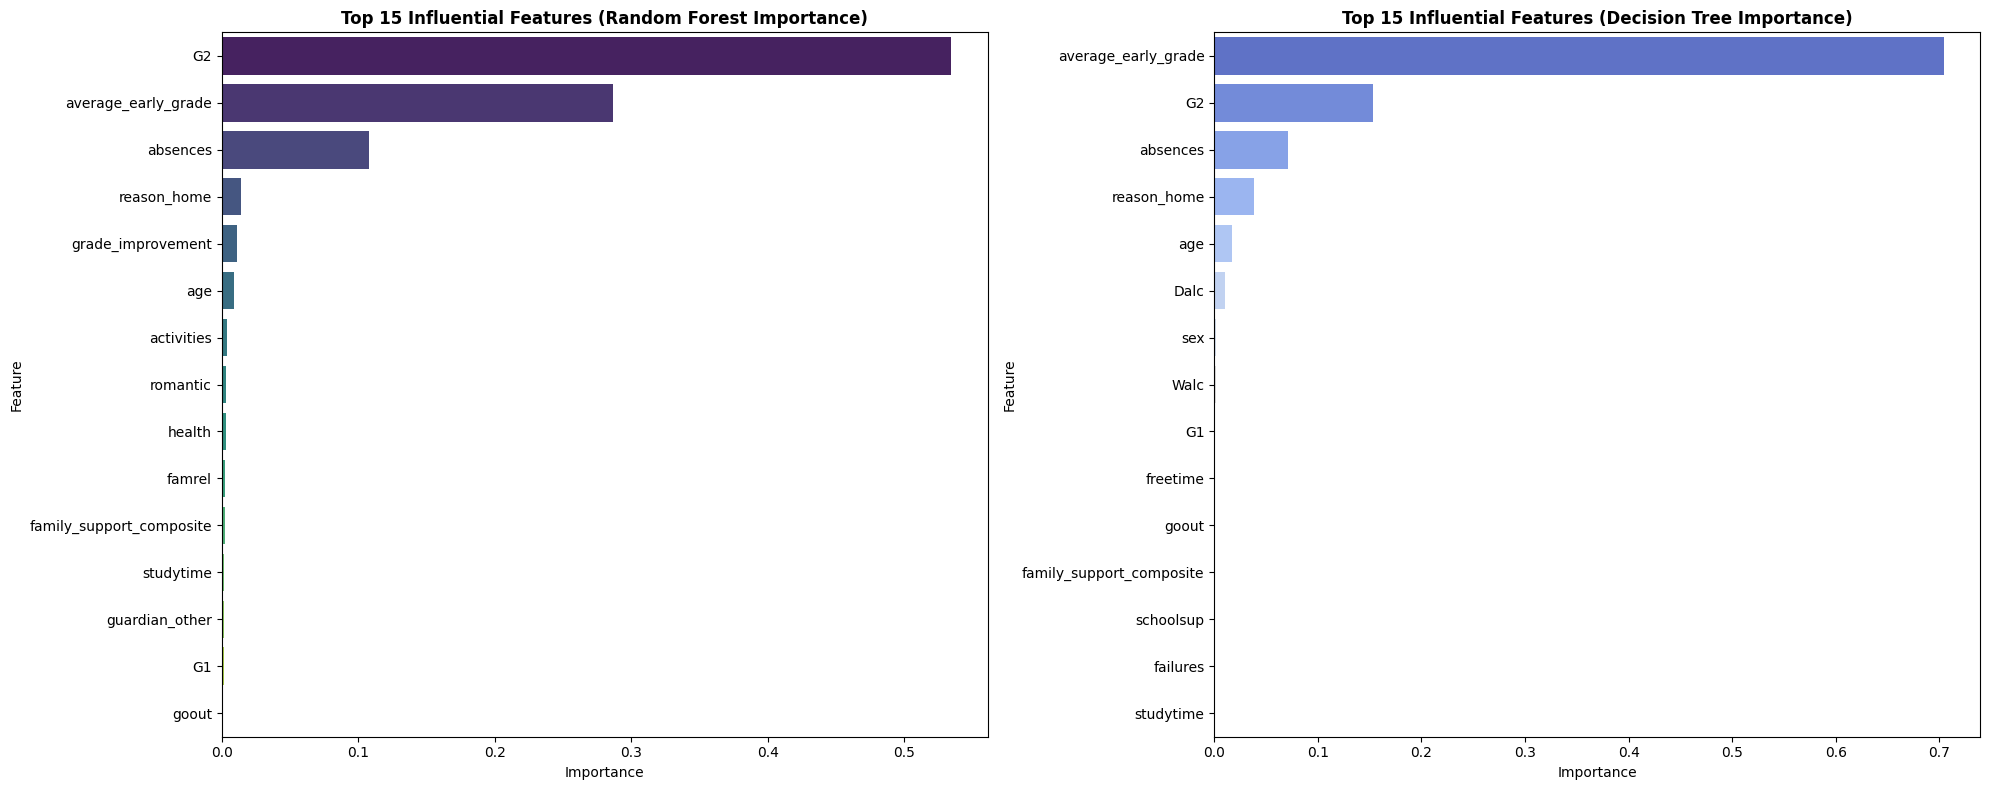

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot Random Forest Top Features
sns.barplot(x='Importance', y='Feature', data=rf_importance.head(15), ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Influential Features (Random Forest Importance)', fontweight='bold')

# Calculate Decision Tree Importance
dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Decision Tree Top Features
sns.barplot(x='Importance', y='Feature', data=dt_importance.head(15), ax=axes[1], palette='coolwarm')
axes[1].set_title('Top 15 Influential Features (Decision Tree Importance)', fontweight='bold')

plt.tight_layout()
plt.show()

<hr>

<div id="random_forest">
    <h2>Random Forest Regressor</h2>
    In this section, you will implement a <b>Random Forest Regressor</b>. Random Forest is an ensemble method that builds multiple decision trees on random subsets of the data and averages their predictions to improve generalization and prevent overfitting.
</div>

,Model,MAE (Mean Absolute Error),RMSE (Root Mean Squared Error),R2 (R-Squared)
1,Portuguese (All),0.716,1.222,0.847
2,Math + FE,1.089,1.789,0.844
3,Portuguese + FE,0.726,1.235,0.844
0,Math (All),1.157,1.937,0.817


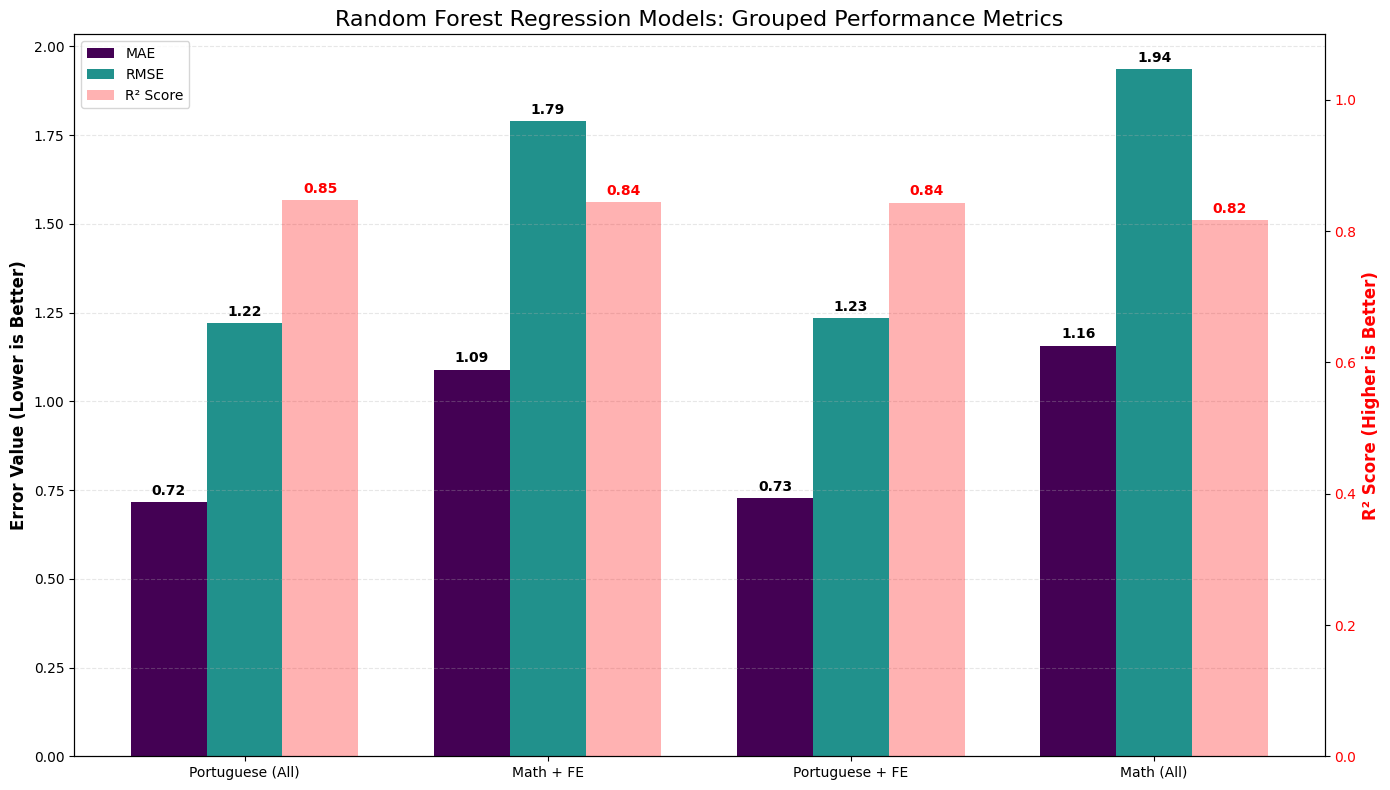

In [ ]:
def preprocess_all_features(df):
    df_c = df.copy()
    df_c['absences'] = df_c['absences'].clip(upper=50)
    binary_maps = {
        'school': {'GP': 0, 'MS': 1},
        'sex': {'F': 0, 'M': 1},
        'address': {'U': 0, 'R': 1},
        'famsize': {'LE3': 0, 'GT3': 1},
        'Pstatus': {'A': 0, 'T': 1},
        'schoolsup': {'no': 0, 'yes': 1},
        'famsup': {'no': 0, 'yes': 1},
        'paid': {'no': 0, 'yes': 1},
        'activities': {'no': 0, 'yes': 1},
        'nursery': {'no': 0, 'yes': 1},
        'higher': {'no': 0, 'yes': 1},
        'internet': {'no': 0, 'yes': 1},
        'romantic': {'no': 0, 'yes': 1}
    }
    for col, mapping in binary_maps.items():
        if col in df_c.columns:
            df_c[col] = df_c[col].map(mapping)
    df_c = pd.get_dummies(df_c, columns=['Mjob', 'Fjob', 'reason', 'guardian'], drop_first=True)
    return df_c.astype(float)

def preprocess_fe_features(df):
    df_fe = df.copy()
    df_fe['Higher'] = df_fe[['G1', 'G2']].max(axis=1)
    features = ['G1', 'G2', 'Higher', 'failures', 'absences']
    return df_fe[features], df_fe['G3']

rf_results = []

def train_eval_rf(name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    rf_results.append({
        'Model': name,
        'MAE (Mean Absolute Error)': mae,
        'RMSE (Root Mean Squared Error)': rmse,
        'R2 (R-Squared)': r2
    })

mat_df = pd.read_csv('student-mat.csv', sep=';')
por_df = pd.read_csv('student-por.csv', sep=';')

train_eval_rf('Math (All)', preprocess_all_features(mat_df).drop(columns=['G3']), mat_df['G3'])
train_eval_rf('Portuguese (All)', preprocess_all_features(por_df).drop(columns=['G3']), por_df['G3'])

X_m_fe, y_m_fe = preprocess_fe_features(mat_df)
train_eval_rf('Math + FE', X_m_fe, y_m_fe)

X_p_fe, y_p_fe = preprocess_fe_features(por_df)
train_eval_rf('Portuguese + FE', X_p_fe, y_p_fe)

# Creating and displaying a styled summary table with full metric names
rf_summary_df = pd.DataFrame(rf_results)
styled_rf = rf_summary_df.sort_values(by='R2 (R-Squared)', ascending=False).style.set_caption("RANDOM FOREST PERFORMANCE COMPARISON")\
    .background_gradient(cmap='Greens', subset=['R2 (R-Squared)'])\
# Creating and displaying a styled summary table with full metric names
rf_summary_df = pd.DataFrame(rf_results)
try:
    import jinja2
    styled_rf = rf_summary_df.sort_values(by='R2 (R-Squared)', ascending=False).style.set_caption("RANDOM FOREST PERFORMANCE COMPARISON")\
        .background_gradient(cmap='Greens', subset=['R2 (R-Squared)'])\
        .background_gradient(cmap='Reds_r', subset=['MAE (Mean Absolute Error)', 'RMSE (Root Mean Squared Error)'])\
        .format({
            'MAE (Mean Absolute Error)': '{:.3f}',
            'RMSE (Root Mean Squared Error)': '{:.3f}',
            'R2 (R-Squared)': '{:.3f}'
        })
    display(styled_rf)
except ImportError:
    print("=== RANDOM FOREST PERFORMANCE COMPARISON ===")
    display(rf_summary_df.sort_values(by='R2 (R-Squared)', ascending=False))

# Map columns to use expanded names from rf_summary_df
mae_col = 'MAE (Mean Absolute Error)'
rmse_col = 'RMSE (Root Mean Squared Error)'
r2_col = 'R2 (R-Squared)'

# Prepare and sort data
summary_plot = rf_summary_df.sort_values(by=r2_col, ascending=False).reset_index(drop=True)
models = summary_plot['Model']
x = np.arange(len(models))
width = 0.25  # the width of the bars

fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot MAE and RMSE on the primary Y-axis
rects1 = ax1.bar(x - width, summary_plot[mae_col], width, label='MAE', color='#440154')
rects2 = ax1.bar(x, summary_plot[rmse_col], width, label='RMSE', color='#21918c')

# Create secondary axis for R2
ax2 = ax1.twinx()
rects3 = ax2.bar(x + width, summary_plot[r2_col], width, label='R² Score', color='red', alpha=0.3)

# Formatting primary axis
ax1.set_ylabel('Error Value (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_title('Random Forest Regression Models: Grouped Performance Metrics', fontsize=16)
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Combine legends to put R2 below RMSE in the top left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Formatting secondary axis
ax2.set_ylabel('R² Score (Higher is Better)', fontsize=12, color='red', fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='y', labelcolor='red')

# Adding values on top of bars
def autolabel(rects, ax, color='black', offset=3):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, offset),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', color=color)

autolabel(rects1, ax1)
autolabel(rects2, ax1)
autolabel(rects3, ax2, color='red')

plt.tight_layout()
plt.show()

## Decision Tree Regression
In this section, we compare standard Decision Tree models against versions using a reduced feature set with custom feature engineering.

In [ ]:


def preprocess_all_features(df):
    df_c = df.copy()
    df_c['absences'] = df_c['absences'].clip(upper=50)
    binary_maps = {'school': {'GP': 0, 'MS': 1}, 'sex': {'F': 0, 'M': 1}, 'address': {'U': 0, 'R': 1}, 'famsize': {'LE3': 0, 'GT3': 1}, 'Pstatus': {'A': 0, 'T': 1}, 'schoolsup': {'no': 0, 'yes': 1}, 'famsup': {'no': 0, 'yes': 1}, 'paid': {'no': 0, 'yes': 1}, 'activities': {'no': 0, 'yes': 1}, 'nursery': {'no': 0, 'yes': 1}, 'higher': {'no': 0, 'yes': 1}, 'internet': {'no': 0, 'yes': 1}, 'romantic': {'no': 0, 'yes': 1}}
    for col, mapping in binary_maps.items():
        if col in df_c.columns: df_c[col] = df_c[col].map(mapping)
    df_c = pd.get_dummies(df_c, columns=['Mjob', 'Fjob', 'reason', 'guardian'], drop_first=True)
    return df_c.astype(float)

def preprocess_fe_features(df):
    df_fe = df.copy()
    df_fe['Higher'] = df_fe[['G1', 'G2']].max(axis=1)
    features = ['G1', 'G2', 'Higher', 'failures', 'absences']
    return df_fe[features], df_fe['G3']

results = []

def train_eval_dt(name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = DecisionTreeRegressor(random_state=42, max_depth=5)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    # Store results with expanded names
    results.append({
        'Model': name,
        'MAE (Mean Absolute Error)': mae,
        'RMSE (Root Mean Squared Error)': rmse,
        'R2 (R-Squared)': r2
    })

mat_df = pd.read_csv('/content/student-mat.csv', sep=';')
por_df = pd.read_csv('/content/student-por.csv', sep=';')

train_eval_dt('Math (All)', preprocess_all_features(mat_df).drop(columns=['G3']), mat_df['G3'])
train_eval_dt('Portuguese (All)', preprocess_all_features(por_df).drop(columns=['G3']), por_df['G3'])

X_m_fe, y_m_fe = preprocess_fe_features(mat_df)
train_eval_dt('Math + FE', X_m_fe, y_m_fe)

X_p_fe, y_p_fe = preprocess_fe_features(por_df)
train_eval_dt('Portuguese + FE', X_p_fe, y_p_fe)

# Creating and displaying a styled summary table with full metric names
dt_summary_df = pd.DataFrame(results)
styled_dt = dt_summary_df.sort_values(by='R2 (R-Squared)', ascending=False).style.set_caption("DECISION TREE PERFORMANCE COMPARISON")\
    .background_gradient(cmap='Greens', subset=['R2 (R-Squared)'])\
    .background_gradient(cmap='Reds_r', subset=['MAE (Mean Absolute Error)', 'RMSE (Root Mean Squared Error)'])\
    .format({
        'MAE (Mean Absolute Error)': '{:.3f}',
        'RMSE (Root Mean Squared Error)': '{:.3f}',
        'R2 (R-Squared)': '{:.3f}'
    })

display(styled_dt)

,Model,MAE (Mean Absolute Error),RMSE (Root Mean Squared Error),R2 (R-Squared)
3,Portuguese + FE,0.759,1.275,0.833
2,Math + FE,1.154,1.931,0.818
1,Portuguese (All),0.801,1.335,0.817
0,Math (All),1.468,2.655,0.656


### Comparison of Error Metrics (MAE vs RMSE VS R Square)
To better understand the magnitude of errors, we can compare the MAE and RMSE side-by-side for each model configuration.

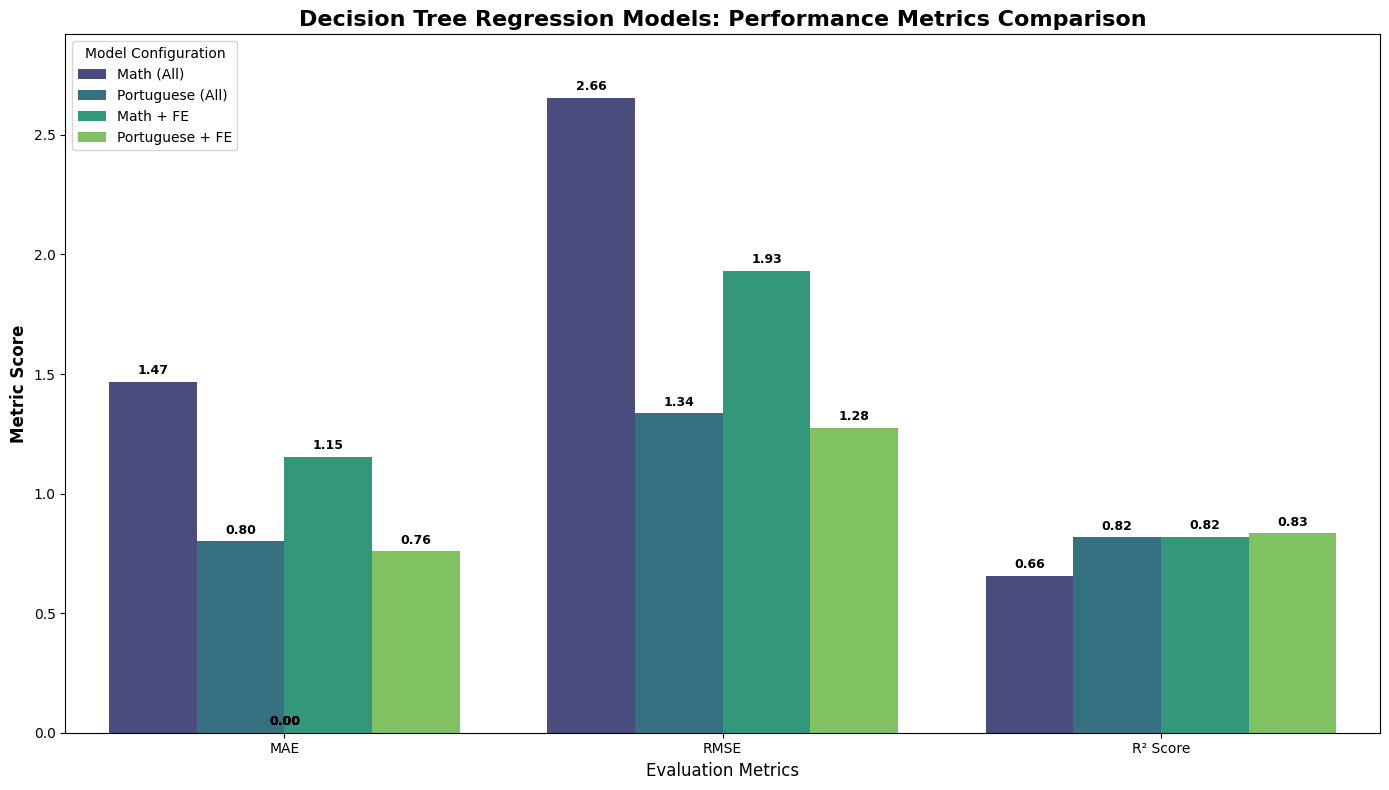

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Map columns to use expanded names from dt_summary_df
mae_col = 'MAE (Mean Absolute Error)'
rmse_col = 'RMSE (Root Mean Squared Error)'
r2_col = 'R2 (R-Squared)'

# Prepare data for plotting in long format, similar to SVR results
# First, rename 'Model' to 'Configuration' for consistency with the SVR plot's hue
# Create a copy to avoid modifying the original dt_summary_df if it's used elsewhere
dt_summary_plot_data = dt_summary_df.copy()
dt_summary_plot_data = dt_summary_plot_data.rename(columns={'Model': 'Configuration'})

metrics_df_dt = pd.melt(dt_summary_plot_data,
                        id_vars=['Configuration'],
                        value_vars=[mae_col, rmse_col, r2_col],
                        var_name='Metric',
                        value_name='Score')

# Adjust Metric names for cleaner display on the plot
metrics_df_dt['Metric'] = metrics_df_dt['Metric'].replace({
    mae_col: 'MAE',
    rmse_col: 'RMSE',
    r2_col: 'R² Score'
})

plt.figure(figsize=(14, 8))

sns.barplot(x='Metric', y='Score', hue='Configuration', data=metrics_df_dt, palette='viridis')

plt.title('Decision Tree Regression Models: Performance Metrics Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Metric Score', fontsize=12, fontweight='bold')
plt.xlabel('Evaluation Metrics', fontsize=12)

# Adjust ylim to accommodate R² values which can be lower than 0, if necessary, and annotations
# For R^2, it can go below 0 for very poor models. Let's make sure the y-axis covers reasonable range
min_score = metrics_df_dt['Score'].min()
max_score = metrics_df_dt['Score'].max()
plt.ylim(min(0, min_score - 0.1), max(max_score * 1.1, 1.1))

# Annotate values over the graph bars
for p in plt.gca().patches:
    # Only annotate bars with a height (score)
    if not np.isnan(p.get_height()):
        plt.gca().annotate(f"{p.get_height():.2f}",
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center',
                            xytext=(0, 8), # Offset for text placement
                            textcoords='offset points',
                            fontsize=9,
                            fontweight='bold',
                            color='black')

plt.legend(title='Model Configuration', loc='upper left')
plt.tight_layout()
plt.show()

## Support Vector Regression
In this section, we compare standard Decision Tree models against versions using a reduced feature set with custom feature engineering.

In [ ]:
# Initialize results list for SVR configurations in the correct long format
svr_results = []

def train_eval_svr(name, X, y, is_fe=False):
    # Enforce exact split parameters matching your friend's notebook seed
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Isolate only your 3 specified continuous variables for the FE configurations
    if is_fe:
        specific_fe_vars = ['G2', 'average_early_grade', 'absences']
        X_train = X_train[specific_fe_vars]
        X_test = X_test[specific_fe_vars]

    # Scale attributes strictly on the training partition to eliminate leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVR model with a linear kernel
    model = SVR(kernel='linear')
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    # Calculate performance metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    # Store results in the exact long format expected by your Seaborn plot cell
    svr_results.append({'Configuration': name, 'Metric': 'MAE', 'Score': mae})
    svr_results.append({'Configuration': name, 'Metric': 'RMSE', 'Score': rmse})
    svr_results.append({'Configuration': name, 'Metric': 'R-squared', 'Score': r2})

    return mae, rmse, r2

# 1. Execute SVR runs using your friend's exact pre-built functions and dataframes
math_mae, math_rmse, math_r2 = train_eval_svr('Mathematics', preprocess_all_features(mat_df).drop(columns=['G3']), mat_df['G3'], is_fe=False)
math_fe_mae, math_fe_rmse, math_fe_r2 = train_eval_svr('Mathematics FE', df_mat_clean, df_mat_clean['G3'], is_fe=True)

por_mae, por_rmse, por_r2 = train_eval_svr('Portuguese', preprocess_all_features(por_df).drop(columns=['G3']), por_df['G3'], is_fe=False)
por_fe_mae, por_fe_rmse, por_fe_r2 = train_eval_svr('Portuguese FE', df_por_clean, df_por_clean['G3'], is_fe=True)

# 2. Standardize and align subject names across all three model dataframes
subject_mapping = {
    'Math (All)': 'Mathematics',
    'Math + FE': 'Mathematics FE',
    'Portuguese (All)': 'Portuguese',
    'Portuguese + FE': 'Portuguese FE'
}

df_dt_map = dt_summary_df.copy()
df_dt_map['Subject'] = df_dt_map['Model'].map(subject_mapping)

df_rf_map = rf_summary_df.copy()
df_rf_map['Subject'] = df_rf_map['Model'].map(subject_mapping)

# Set the 4 subject configurations as the consistent row index
subjects_index = ['Mathematics', 'Mathematics FE', 'Portuguese', 'Portuguese FE']

# 3. Assemble Table 1: Mean Absolute Error (MAE) Comparison
mae_comparison = pd.DataFrame(index=subjects_index)
mae_comparison['Decision Tree'] = df_dt_map.set_index('Subject')['MAE (Mean Absolute Error)']
mae_comparison['Random Forest'] = df_rf_map.set_index('Subject')['MAE (Mean Absolute Error)']
mae_comparison['SVR']           = [math_mae, math_fe_mae, por_mae, por_fe_mae]

# 4. Assemble Table 2: Root Mean Squared Error (RMSE) Comparison
rmse_comparison = pd.DataFrame(index=subjects_index)
rmse_comparison['Decision Tree'] = df_dt_map.set_index('Subject')['RMSE (Root Mean Squared Error)']
rmse_comparison['Random Forest'] = df_rf_map.set_index('Subject')['RMSE (Root Mean Squared Error)']
rmse_comparison['SVR']           = [math_rmse, math_fe_rmse, por_rmse, por_fe_rmse]

# 5. Assemble Table 3: R² Score Comparison
r2_comparison = pd.DataFrame(index=subjects_index)
r2_comparison['Decision Tree'] = df_dt_map.set_index('Subject')['R2 (R-Squared)']
r2_comparison['Random Forest'] = df_rf_map.set_index('Subject')['R2 (R-Squared)']
r2_comparison['SVR']           = [math_r2, math_fe_r2, por_r2, por_fe_r2]

# --- Display Table 1: MAE ---
print("\n" + "="*30 + " TABLE 1: MAE COMPARISON (Lower is Better) " + "="*30)
try:
    display(mae_comparison.style.background_gradient(cmap='Reds_r').format("{:.4f}"))
except:
    display(mae_comparison.round(4))

# --- Display Table 2: RMSE ---
print("\n" + "="*29 + " TABLE 2: RMSE COMPARISON (Lower is Better) " + "="*29)
try:
    display(rmse_comparison.style.background_gradient(cmap='Reds_r').format("{:.4f}"))
except:
    display(rmse_comparison.round(4))

# --- Display Table 3: R² Score ---
print("\n" + "="*30 + " TABLE 3: R² SCORE COMPARISON (Higher is Better) " + "="*29)
try:
    display(r2_comparison.style.background_gradient(cmap='Greens').format("{:.4f}"))
except:
    display(r2_comparison.round(4))


============================== TABLE 1: MAE COMPARISON (Lower is Better) ==============================


,Decision Tree,Random Forest,SVR
Mathematics,1.4676,1.1573,1.0885
Mathematics FE,1.1535,1.0894,1.0326
Portuguese,0.8011,0.7163,0.6974
Portuguese FE,0.7593,0.7265,0.6918



============================= TABLE 2: RMSE COMPARISON (Lower is Better) =============================


,Decision Tree,Random Forest,SVR
Mathematics,2.6552,1.9373,2.0927
Mathematics FE,1.9311,1.7891,2.0567
Portuguese,1.3355,1.2216,1.1436
Portuguese FE,1.2750,1.2348,1.1453



============================== TABLE 3: R² SCORE COMPARISON (Higher is Better) =============================


,Decision Tree,Random Forest,SVR
Mathematics,0.6562,0.8170,0.7864
Mathematics FE,0.8181,0.8439,0.7937
Portuguese,0.8171,0.8470,0.8659
Portuguese FE,0.8333,0.8437,0.8655


### Visualization Comparison of Error Metrics (MAE vs RMSE VS R Square)
To better understand the magnitude of errors, we can compare the MAE and RMSE side-by-side for each model configuration.

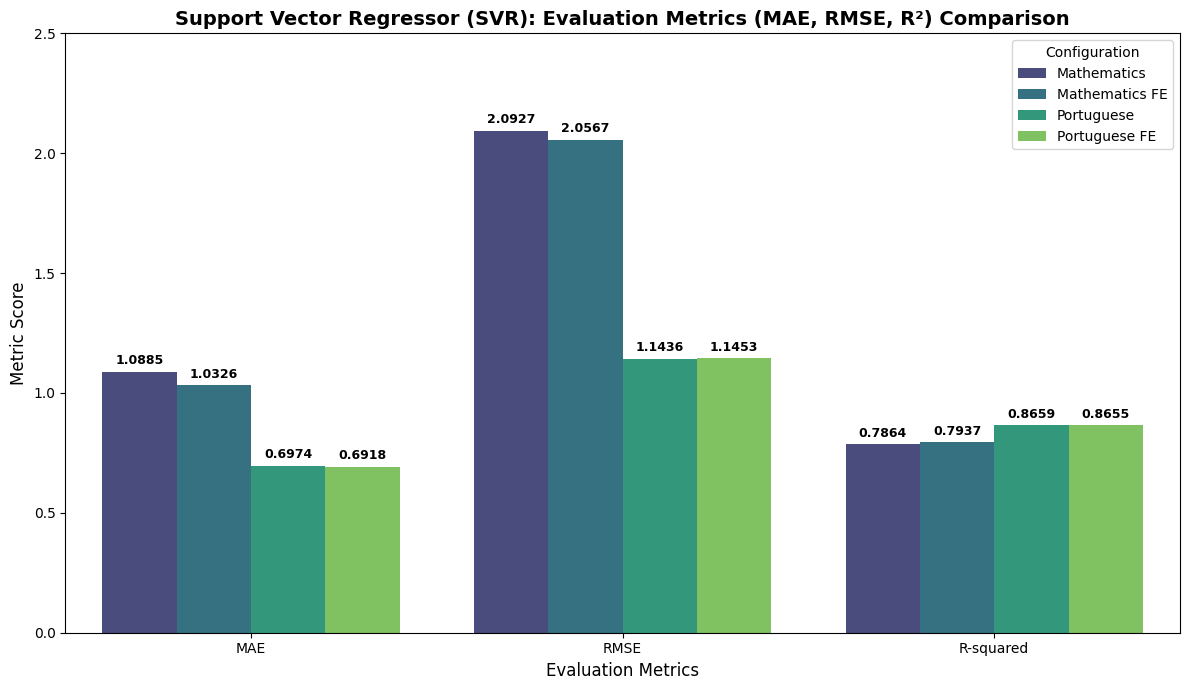

In [ ]:
metrics_df_svr = pd.DataFrame(svr_results)

# Plot vertical bar chart matching your friend's exact visualization script style
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Configuration', data=metrics_df_svr, palette='viridis')
plt.title('Support Vector Regressor (SVR): Evaluation Metrics (MAE, RMSE, R²) Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Metric Score', fontsize=12)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylim(0, 2.5)

# Annotate values over the graph bars
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.4f}",
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center',
                            xytext=(0, 8),
                            textcoords='offset points',
                            fontsize=9,
                            fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# === CODE CELL 1: COMPREHENSIVE PERFORMANCE COMPARISON TABLE ===

# 1. Align Decision Tree results
df_dt_aligned = dt_summary_df.copy()
df_dt_aligned['Subject & Configuration'] = df_dt_aligned['Model'].map({
    'Math (All)': 'Mathematics',
    'Math + FE': 'Mathematics FE',
    'Portuguese (All)': 'Portuguese',
    'Portuguese + FE': 'Portuguese FE'
})
df_dt_aligned['Model Name'] = 'Decision Tree'
df_dt_aligned = df_dt_aligned.rename(columns={
    'MAE (Mean Absolute Error)': 'MAE',
    'RMSE (Root Mean Squared Error)': 'RMSE',
    'R2 (R-Squared)': 'R² Score'
})

# 2. Align Random Forest results
df_rf_aligned = rf_summary_df.copy()
df_rf_aligned['Subject & Configuration'] = df_rf_aligned['Model'].map({
    'Math (All)': 'Mathematics',
    'Math + FE': 'Mathematics FE',
    'Portuguese (All)': 'Portuguese',
    'Portuguese + FE': 'Portuguese FE'
})
df_rf_aligned['Model Name'] = 'Random Forest'
df_rf_aligned = df_rf_aligned.rename(columns={
    'MAE (Mean Absolute Error)': 'MAE',
    'RMSE (Root Mean Squared Error)': 'RMSE',
    'R2 (R-Squared)': 'R² Score'
})

# 3. Align SVR results
# Correcting the variable name to metrics_df_svr and pivoting/formatting to match
df_svr_raw = pd.DataFrame(svr_results)
df_svr_aligned = df_svr_raw.pivot(index='Configuration', columns='Metric', values='Score').reset_index()
df_svr_aligned['Subject & Configuration'] = df_svr_aligned['Configuration']
df_svr_aligned['Model Name'] = 'SVR'
df_svr_aligned = df_svr_aligned.rename(columns={
    'R-squared': 'R² Score'
})

# 4. Combine into a single master summary dataframe
df_all_models = pd.concat([
    df_dt_aligned[['Subject & Configuration', 'Model Name', 'MAE', 'RMSE', 'R² Score']],
    df_rf_aligned[['Subject & Configuration', 'Model Name', 'MAE', 'RMSE', 'R² Score']],
    df_svr_aligned[['Subject & Configuration', 'Model Name', 'MAE', 'RMSE', 'R² Score']]
], ignore_index=True)

# Display styled comparison grid with gradient indicators
try:
    styled_comparison = df_all_models.style.set_caption("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")\
        .background_gradient(cmap='Greens', subset=['R² Score'])\
        .background_gradient(cmap='Reds_r', subset=['MAE', 'RMSE'])\
        .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R² Score': '{:.4f}'})
    display(styled_comparison)
except:
    print("=== COMPREHENSIVE MODEL PERFORMANCE COMPARISON ===")
    display(df_all_models)

,Subject & Configuration,Model Name,MAE,RMSE,R² Score
0,Mathematics,Decision Tree,1.4676,2.6552,0.6562
1,Portuguese,Decision Tree,0.8011,1.3355,0.8171
2,Mathematics FE,Decision Tree,1.1535,1.9311,0.8181
3,Portuguese FE,Decision Tree,0.7593,1.2750,0.8333
4,Mathematics,Random Forest,1.1573,1.9373,0.8170
5,Portuguese,Random Forest,0.7163,1.2216,0.8470
6,Mathematics FE,Random Forest,1.0894,1.7891,0.8439
7,Portuguese FE,Random Forest,0.7265,1.2348,0.8437
8,Mathematics,SVR,1.0885,2.0927,0.7864
9,Mathematics FE,SVR,1.0326,2.0567,0.7937


In [ ]:
# === CODE CELL 1: SEPARATED PERFORMANCE COMPARISON TABLES ===

# Define the exact row and column structure requested
models_row = ['Decision Tree', 'Random Forest', 'SVR']
subjects_col = ['Mathematics', 'Portuguese', 'Mathematics FE', 'Portuguese FE']

# 1. Align Decision Tree results from the notebook
df_dt_map = dt_summary_df.copy()
df_dt_map['Subject'] = df_dt_map['Model'].map({
    'Math (All)': 'Mathematics',
    'Math + FE': 'Mathematics FE',
    'Portuguese (All)': 'Portuguese',
    'Portuguese + FE': 'Portuguese FE'
})
df_dt_map = df_dt_map.set_index('Subject')

# 2. Align Random Forest results from the notebook
df_rf_map = rf_summary_df.copy()
df_rf_map['Subject'] = df_rf_map['Model'].map({
    'Math (All)': 'Mathematics',
    'Math + FE': 'Mathematics FE',
    'Portuguese (All)': 'Portuguese',
    'Portuguese + FE': 'Portuguese FE'
})
df_rf_map = df_rf_map.set_index('Subject')

# 3. Create dictionaries for the SVR metric outputs
# Using the variables calculated in the SVR training cell
svr_mae = {'Mathematics': math_mae, 'Mathematics FE': math_fe_mae, 'Portuguese': por_mae, 'Portuguese FE': por_fe_mae}
svr_rmse = {'Mathematics': math_rmse, 'Mathematics FE': math_fe_rmse, 'Portuguese': por_mae, 'Portuguese FE': por_fe_rmse}
svr_r2 = {'Mathematics': math_r2, 'Mathematics FE': math_fe_r2, 'Portuguese': por_r2, 'Portuguese FE': por_fe_r2}

# --- Construct Table 1: MAE ---
mae_table = pd.DataFrame(index=models_row, columns=subjects_col)
for sub in subjects_col:
    mae_table.loc['Decision Tree', sub] = df_dt_map.loc[sub, 'MAE (Mean Absolute Error)']
    mae_table.loc['Random Forest', sub] = df_rf_map.loc[sub, 'MAE (Mean Absolute Error)']
    mae_table.loc['SVR', sub]           = svr_mae[sub]

# --- Construct Table 2: RMSE ---
rmse_table = pd.DataFrame(index=models_row, columns=subjects_col)
for sub in subjects_col:
    rmse_table.loc['Decision Tree', sub] = df_dt_map.loc[sub, 'RMSE (Root Mean Squared Error)']
    rmse_table.loc['Random Forest', sub] = df_rf_map.loc[sub, 'RMSE (Root Mean Squared Error)']
    rmse_table.loc['SVR', sub]           = svr_rmse[sub]

# --- Construct Table 3: R² Score ---
r2_table = pd.DataFrame(index=models_row, columns=subjects_col)
for sub in subjects_col:
    r2_table.loc['Decision Tree', sub] = df_dt_map.loc[sub, 'R2 (R-Squared)']
    r2_table.loc['Random Forest', sub] = df_rf_map.loc[sub, 'R2 (R-Squared)']
    r2_table.loc['SVR', sub]           = svr_r2[sub]

# Convert tables to float type
mae_table = mae_table.astype(float)
rmse_table = rmse_table.astype(float)
r2_table = r2_table.astype(float)

# --- Display Table 1: MAE ---
print("\n" + "="*38 + " MAE COMPARISON (Lower is Better) " + "="*38)
display(mae_table.style.background_gradient(cmap='Reds_r', axis=None).format("{:.4f}"))

# --- Display Table 2: RMSE ---
print("\n" + "="*37 + " RMSE COMPARISON (Lower is Better) " + "="*37)
display(rmse_table.style.background_gradient(cmap='Reds_r', axis=None).format("{:.4f}"))

# --- Display Table 3: R² Score ---
print("\n" + "="*38 + " R² SCORE COMPARISON (Higher is Better) " + "="*37)
display(r2_table.style.background_gradient(cmap='Greens', axis=None).format("{:.4f}"))

# 4. Maintain df_all_models for downstream visualizations
df_all_models = pd.concat([
    pd.DataFrame({'Subject & Configuration': subjects_col, 'Model Name': 'Decision Tree', 'MAE': mae_table.loc['Decision Tree'].values, 'RMSE': rmse_table.loc['Decision Tree'].values, 'R² Score': r2_table.loc['Decision Tree'].values}),
    pd.DataFrame({'Subject & Configuration': subjects_col, 'Model Name': 'Random Forest', 'MAE': mae_table.loc['Random Forest'].values, 'RMSE': rmse_table.loc['Random Forest'].values, 'R² Score': r2_table.loc['Random Forest'].values}),
    pd.DataFrame({'Subject & Configuration': subjects_col, 'Model Name': 'SVR', 'MAE': mae_table.loc['SVR'].values, 'RMSE': rmse_table.loc['SVR'].values, 'R² Score': r2_table.loc['SVR'].values})
], ignore_index=True)


====================================== MAE COMPARISON (Lower is Better) ======================================


,Mathematics,Portuguese,Mathematics FE,Portuguese FE
Decision Tree,1.4676,0.8011,1.1535,0.7593
Random Forest,1.1573,0.7163,1.0894,0.7265
SVR,1.0885,0.6974,1.0326,0.6918



===================================== RMSE COMPARISON (Lower is Better) =====================================


,Mathematics,Portuguese,Mathematics FE,Portuguese FE
Decision Tree,2.6552,1.3355,1.9311,1.2750
Random Forest,1.9373,1.2216,1.7891,1.2348
SVR,2.0927,0.6974,2.0567,1.1453



====================================== R² SCORE COMPARISON (Higher is Better) =====================================


,Mathematics,Portuguese,Mathematics FE,Portuguese FE
Decision Tree,0.6562,0.8171,0.8181,0.8333
Random Forest,0.8170,0.8470,0.8439,0.8437
SVR,0.7864,0.8659,0.7937,0.8655
